In [1]:
import pandas

df = pandas.read_csv("exp/clustering/fbank80_stmn_ecapatdnn512x3.v3.0.s1/kmeans/voxceleb2cat_full/speaker/20_clusters/segments_kmeans.csv")
list = df.to_numpy().tolist()

In [12]:
dict_of_dict = {}

for i, row in df.iterrows():
        cluster = row['cluster']
        speaker = row['speaker']
        dist = row['dist_from_center']

        if cluster not in dict_of_dict:
            dict_of_dict[cluster] = {}

        if speaker not in dict_of_dict[cluster]:
            dict_of_dict[cluster][speaker] = dist

In [26]:
target_speakers = {}
df_full = pandas.read_csv("data/voxceleb2cat_full/speaker.csv")

for c in dict_of_dict:
    min_key = min(dict_of_dict[c], key=dict_of_dict[c].get)
    min_value = dict_of_dict[c][min_key]

    print(min_key)
    print(min_value)

    class_id = df_full.loc[df_full['id'] == min_key]['class_idx'].values[0]

    target_speakers[c] = class_id   

id01590
25.64426715725906
id06704
18.906740530957396
id05262
28.457496280951812
id06591
23.719022464242727
id06716
23.21680333260217
id05405
14.610185196070244
id00656
23.75358360389216
id06862
20.99196248849416
id01130
27.17837798962592
id04717
24.16236867380712
id08404
17.413740315038122
id09153
30.58999831226904
id07122
26.81674287707829
id07517
23.55584906237036
id02211
31.750028324932487
id07571
26.16141109754792
id03904
36.304736757659526
id06388
29.93047073845623
id08768
40.75965388096347
id01800
25.88348185384097


In [24]:
target_speakers

{7: 1081,
 15: 4324,
 8: 3421,
 19: 4269,
 5: 4331,
 18: 3510,
 6: 436,
 3: 4419,
 14: 764,
 12: 3079,
 16: 5430,
 9: 5923,
 4: 4597,
 10: 4856,
 17: 1509,
 1: 4901,
 13: 2508,
 2: 4132,
 11: 5697,
 0: 1234}

In [16]:
min_key = min(dict_of_dict[1], key=dict_of_dict[1].get)
min_value = dict_of_dict[1][min_key]

In [17]:
min_key

'id07571'

In [18]:
min_value

26.16141109754792

In [14]:
dict_of_dict[1].values()

dict_values([45.2261134436049, 54.0445777561439, 49.156884485721264, 54.79287315443179, 46.5139612667965, 57.05389284463684, 61.99089373836127, 51.79049062104675, 75.96571128052673, 51.59285422264823, 64.01360785410394, 56.92771854565166, 60.351338048567726, 44.58648586275282, 59.56800709330327, 67.74553873977332, 59.00085560560427, 70.35231740842192, 88.0129740419229, 39.44267129641532, 73.31641344776752, 59.38296413179029, 41.99303312135918, 72.40531544379004, 86.07609008845384, 73.0486054299197, 44.31415585489276, 76.83093644242614, 39.009705198749046, 56.55699723648098, 47.84641985644676, 56.12626869604875, 54.75107544160296, 46.74719322714105, 70.02172881811934, 66.46032657615818, 87.17965941070274, 61.58930251563726, 83.03381089211865, 41.00007888123247, 75.42688996086356, 34.85897536908297, 28.598809952424222, 46.59479343869209, 59.09286590027055, 76.64047684448892, 73.49158442169772, 62.18912366357351, 65.87901538442216, 76.9471139491582, 88.69087351543098, 76.69207673642558, 5

In [20]:
df_full = pandas.read_csv("data/voxceleb2cat_full/speaker.csv")
seg_df = {}

In [22]:
seg_df = {}

for c in dict_of_dict:
    seg_df[c] = []
    for seg_id in dict_of_dict[c]['seg_id']:
        
        if seg_id in df_full['id'].values:

            row = df_full[df_full['id'] == seg_id].iloc[0].to_dict()
            seg_df[c].append(row)

In [24]:
df = pandas.DataFrame(seg_df[0])

,id,video_ids,speaker,gender,language_est,language_est_conf,duration
0,id00022-8h_eBmBYH3Q,8h_eBmBYH3Q,id00022,f,urdu,0.91,7.921000
1,id00022-ZZ8QOutt1NI,ZZ8QOutt1NI,id00022,f,tagalog,0.84,4.711000
2,id00024-3ysHAigPe68,3ysHAigPe68,id00024,f,welsh,0.94,83.833187
3,id00024-8wJl8BMFV3A,8wJl8BMFV3A,id00024,f,welsh,0.96,34.319437
4,id00024-FNTXmLdGA8s,FNTXmLdGA8s,id00024,f,welsh,0.96,89.014437
...,...,...,...,...,...,...,...
864,id00752-qPh5cFKUay8,qPh5cFKUay8,id00752,f,english,0.96,78.509000
865,id00752-r1IXpFoI-qc,r1IXpFoI-qc,id00752,f,english,0.94,98.696500
866,id00752-sDpKNDnVcZw,sDpKNDnVcZw,id00752,f,english,0.98,21.727687
867,id00752-yJXgpQNX4ow,yJXgpQNX4ow,id00752,f,english,0.96,48.239812


In [4]:
sum_dist = {}

for c in dict_of_dict:
    speakers = dict_of_dict[c]['speaker']

    print(c)
    sum_dist[c] = {}
    for i in range(len(speakers)):
        if speakers[i] not in sum_dist[c]:
            sum_dist[c][speakers[i]] = {}
            sum_dist[c][speakers[i]]['dist'] = dict_of_dict[c]['dist_from_center'][i]
            sum_dist[c][speakers[i]]['count'] = 1
        else:
            sum_dist[c][speakers[i]]['dist'] = sum_dist[c][speakers[i]]['dist'] + dict_of_dict[c]['dist_from_center'][i]
            sum_dist[c][speakers[i]]['count'] = sum_dist[c][speakers[i]]['count'] + 1
    
        sum_dist[c][speakers[i]]['avg_dist'] = sum_dist[c][speakers[i]]['dist']/sum_dist[c][speakers[i]]['count']

0
7
4
6
1
5
3
2


In [38]:
print(dict_of_dict[0]['speaker'][0])
print(dict_of_dict[0]['seg_id'][0])
print(dict_of_dict[0]['dist_from_center'][0])

id00012
id00012-21Uxsk56VDQ
235.6920741198036


In [42]:
sum_dist

{0: {'id00012': {'dist': 3352.0732452550337,
   'count': 20,
   'avg_dist': 167.6036622627517},
  'id00018': {'dist': 4556.3127568791,
   'count': 23,
   'avg_dist': 198.10055464691737},
  'id00019': {'dist': 4566.431227091436,
   'count': 21,
   'avg_dist': 217.44910605197316},
  'id00020': {'dist': 7824.789207341819,
   'count': 38,
   'avg_dist': 205.91550545636366},
  'id00021': {'dist': 1113.9094748991008,
   'count': 10,
   'avg_dist': 111.39094748991008},
  'id00026': {'dist': 219.07902461824008,
   'count': 1,
   'avg_dist': 219.07902461824008},
  'id00033': {'dist': 203.9160348305744,
   'count': 1,
   'avg_dist': 203.9160348305744},
  'id00046': {'dist': 135.3849562494249,
   'count': 1,
   'avg_dist': 135.3849562494249},
  'id00047': {'dist': 6870.41395902339,
   'count': 23,
   'avg_dist': 298.7136503923213},
  'id00050': {'dist': 2527.883367368793,
   'count': 14,
   'avg_dist': 180.56309766919952},
  'id00051': {'dist': 7873.023202528179,
   'count': 36,
   'avg_dist': 21

In [48]:
target_speakers = {}

min = 10000
min_s = -1

for c, values in sum_dist.items():
    print(c)
    for s, values in values.items():
        print(s)
        #print(values['avg_dist'])
        avg_dist = values['avg_dist']
        if avg_dist < min and values['count'] > 10:
            min = avg_dist
            min_s = s

    print('cluster', c)
    print('min_spk', min_s)
    target_speakers[c] = min_s
    min = 10000
    min_s = -1


0
id00012
id00018
id00019
id00020
id00021
id00026
id00033
id00046
id00047
id00050
id00051
id00052
id00053
id00056
id00059
id00060
id00062
id00063
id00064
id00066
id00073
id00074
id00088
id00096
id00161
id00165
id00168
id00169
id00170
id00173
cluster 0
min_spk id00056
7
id00015
id00020
id00022
id00026
id00027
id00028
id00029
id00033
id00035
id00036
id00039
id00040
id00042
id00043
id00044
id00046
id00049
id00058
id00059
id00060
id00064
id00066
id00067
id00068
id00069
id00070
id00073
id00074
id00075
id00076
id00078
id00079
id00082
id00083
id00084
id00085
id00086
id00087
id00088
id00089
id00090
id00091
id00096
id00104
id00105
id00109
id00111
id00114
id00116
id00117
id00126
id00127
id00128
id00129
id00134
id00146
id00151
id00159
id00161
id00163
id00164
id00165
id00166
id00167
id00169
id00171
id00173
cluster 7
min_spk id00046
4
id00016
id00020
id00028
id00033
id00040
id00055
id00087
id00089
cluster 4
min_spk id00055
6
id00024
id00025
id00026
id00035
id00039
id00042
id00043
id00044
id00052
id

In [49]:
target_speakers

{0: 'id00056',
 7: 'id00046',
 4: 'id00055',
 6: 'id00092',
 1: 'id00099',
 5: 'id00032',
 3: 'id00080',
 2: 'id00097'}

In [92]:
len(dict_of_dict[0]['seg_id'])

433

In [17]:
dict_of_dict

{14: {'seg_id': ['id00012-21Uxsk56VDQ',
   'id00012-2DLq_Kkc1r8',
   'id00012-IYaT706uSpQ',
   'id00012-Pdni5zyZJYA',
   'id00012-UiPa-HfABJQ',
   'id00012-uCBekiUm-rE',
   'id00021-zUAQ0hwQOlg',
   'id00029-96Z18I2UKAE',
   'id00029-9gE-_vyJmFQ',
   'id00029-BrWulfu1gZQ',
   'id00029-CKIhrXa50Mc',
   'id00029-DdcgK2QEuEQ',
   'id00029-ENbtqqJvDP8',
   'id00029-F3jNfK4Wg00',
   'id00029-Gn8fK6Jti1c',
   'id00029-HduYzc9sLKQ',
   'id00029-KVCtKA7xUVg',
   'id00029-PH9k6PZMSlQ',
   'id00029-S4IT_ZENTO8',
   'id00029-T5adauKTAMA',
   'id00029-TGpCGl036qk',
   'id00029-UVFvGPB6z_Y',
   'id00029-VPrmF4Mfd54',
   'id00029-WMJiFtRmoG0',
   'id00029-aHzS49-YrvQ',
   'id00029-alyv5QMCaRc',
   'id00029-az5_ktpTbIw',
   'id00029-jzHTvS_6y7A',
   'id00029-lL2_nvAUIbg',
   'id00029-rUKShbcz9aI',
   'id00029-tDIvM3iVBTY',
   'id00029-tLQri3p72fI',
   'id00029-uY8PpVWdB54',
   'id00029-vbSVgopf1kk',
   'id00029-wSyDzg3pkGs',
   'id00029-y3-5YPS1GnM',
   'id00046-kMFDhPuOc2g',
   'id00046-sGdPQMj8RbQ'

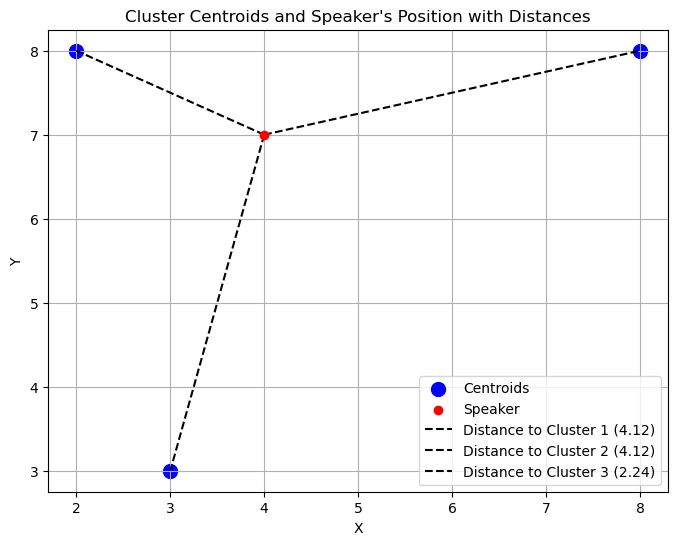

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Example data: cluster centroids and the speaker's position
cluster_centroids = np.array([
    [3, 3],  # Centroid of Cluster 1
    [8, 8],  # Centroid of Cluster 2
    [2, 8]   # Centroid of Cluster 3
])

# Speaker's position (example)
speaker_position = np.array([4, 7])

# Compute the distance from the speaker to each centroid
distances = np.linalg.norm(cluster_centroids - speaker_position, axis=1)

# Plot the centroids and the speaker position
plt.figure(figsize=(8, 6))

# Plot each centroid
plt.scatter(cluster_centroids[:, 0], cluster_centroids[:, 1], color='blue', label='Centroids', s=100)

# Plot the speaker's position
plt.scatter(speaker_position[0], speaker_position[1], color='red', label='Speaker', zorder=5)

# Plot the distance lines from the speaker to each centroid
for i, centroid in enumerate(cluster_centroids):
    plt.plot([speaker_position[0], centroid[0]], [speaker_position[1], centroid[1]], 'k--', label=f'Distance to Cluster {i+1} ({distances[i]:.2f})')

# Add labels and legend
plt.title("Cluster Centroids and Speaker's Position with Distances")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend(loc="best")
plt.show()
